<a href="https://colab.research.google.com/github/erdijova/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_6_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Statistical Machine Learning (VERY COMPLETE VERSION)

This notebook is a detailed and extended version aligned with *Practical Statistics for Data Scientists*.

Focus: practical machine learning methods grounded in statistical thinking.

## Introduction

Statistical Machine Learning combines statistics and algorithms to make predictions.

This chapter includes:
- K-Nearest Neighbors (KNN)
- Tree Models
- Random Forest
- Boosting
- Overfitting & Regularization

We focus on intuition + implementation.

## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier


## Load Dataset

In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = df[['Survived','Pclass','Sex','Age','Fare']].dropna()
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df.head()


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


## Train-Test Split

In [3]:

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Standardization

Important for distance-based models like KNN.

In [4]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## K-Nearest Neighbors (KNN)

Predicts based on nearest neighbors.

Key idea: similar data points are close in feature space.

In [5]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))


KNN Accuracy: 0.7762237762237763


## Choosing K (Hyperparameter Tuning)

Choosing the right K is critical.

Too small → overfitting
Too large → underfitting

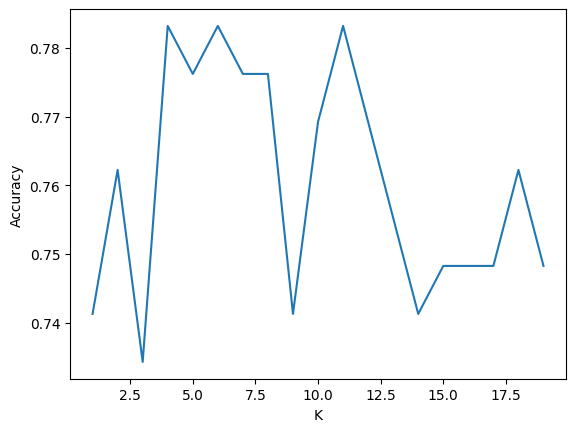

In [6]:

scores = []
k_range = range(1,20)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred))

plt.plot(k_range, scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()


## Decision Trees

Tree models split data recursively.

Advantages:
- Easy to interpret
- Handles nonlinear relationships

In [7]:

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
print("Tree Accuracy:", accuracy_score(y_test, pred_tree))


Tree Accuracy: 0.7552447552447552


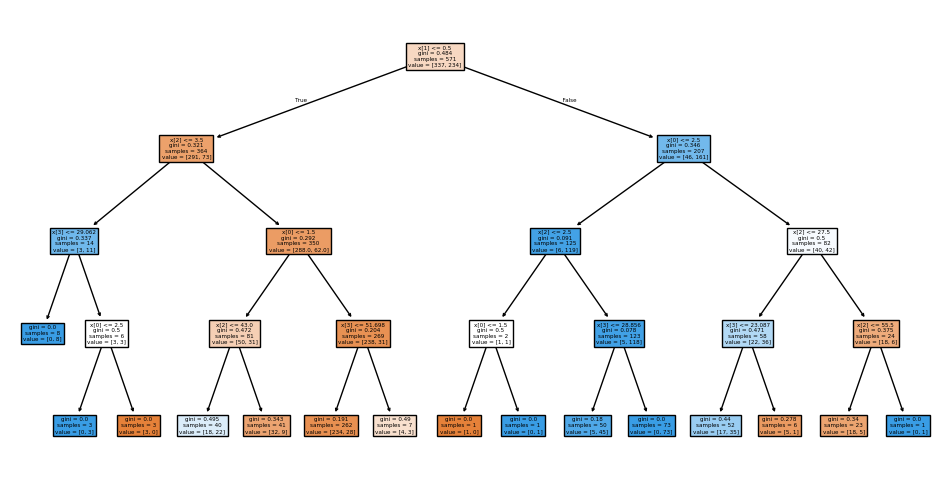

In [8]:

plt.figure(figsize=(12,6))
plot_tree(tree, filled=True)
plt.show()


## Random Forest

Ensemble of decision trees.

Reduces overfitting and improves accuracy.

In [9]:

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))


Random Forest Accuracy: 0.7692307692307693


## Feature Importance

Random Forest can estimate feature importance.

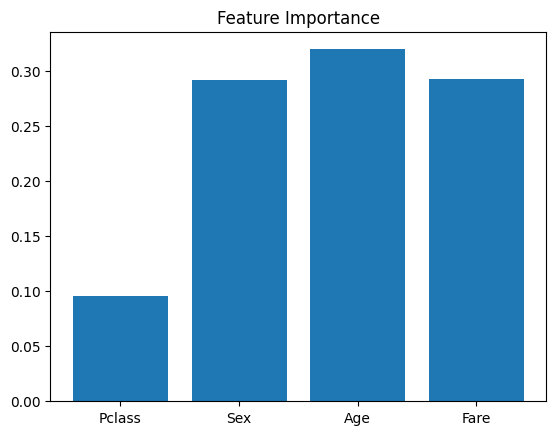

In [10]:

importances = rf.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()


## Boosting (Gradient Boosting)

Boosting builds models sequentially.

Each model corrects previous errors.

In [11]:

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, pred_gb))


Boosting Accuracy: 0.7692307692307693


## Overfitting vs Underfitting

- Overfitting: too complex
- Underfitting: too simple

Goal: balance bias & variance

## Cross Validation

Used to evaluate model performance more reliably.

In [12]:

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Scores:", scores)
print("Mean:", scores.mean())


CV Scores: [0.72027972 0.83916084 0.83916084 0.78321678 0.85915493]
Mean: 0.8081946222791293


## Conclusion

We explored:
- KNN
- Decision Trees
- Random Forest
- Boosting
- Feature importance
- Cross-validation

These are core ML techniques used in real-world systems.